# PI-HGAT NZEB Retrofit Pipeline — ICAE 2026

**Integrated decision-support framework for hot-humid NZEB office retrofits, Ho Chi Minh City.**
Case study: DOE Medium Office prototype (4,982 m2), baseline EUI 122.1 kWh/m2/yr, Koppen Aw.

This notebook is the single end-to-end runner; it mirrors the framework figure
(`results/figures/0. FRAMEWORK DEMO.png`) part by part:

| Framework block | Notebook sections | Key inputs | Outputs |
|---|---|---|---|
| **PART 0 — Data Input (Building/Urban/Graph)** | S1 | `data/registry/neo4j_query_table_data_2026-6-2.json` | PyG-ready KG topology |
| **PART 0 — Simulation & Calibration (offline)** | S2–3 | `data/aggregated_LHS_results.csv` (9 climate x 250 LHS, built by `scripts/data/aggregate_lhs_results.py`) | X (11 features), Y (EUI) |
| **PART 1 — AI-based Prediction** | S4–S10 | HeteroData graphs | trained PI-HGAT + baselines, Fig. 5 |
| **PART 2 — Multi-Objective Optimization** | S11–S13 | surrogate f1 + `pi_hgat/objectives.py` (f2 LCC, f3 LCE) | Pareto set, TOPSIS ranking, Fig. 6–9, 11 |
| **PART 3 — XAI & Recommendations** | S14 | trained model + Pareto optimum | GNNExplainer subgraph, trade-off report |

**Economic/LCA basis (locked 2026-07-02):** 20-yr study period, 8% real discount, elec 0.137 USD/kWh
(EVN before-VAT), grid EF 0.6592 kgCO2e/kWh (MONRE 1726/2024), PV yield 1,420 kWh/kWp/yr.
All constants live in `pi_hgat/config.py`; sourced registry: `data/jEPlus-LHS/ICAE2026_DataRegistry_P1-P9.xlsx`.


In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDL
from torch_geometric.loader import DataLoader as PyGDL
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import xgboost as xgb

from pi_hgat.config import *
from pi_hgat.graph_builder import GraphBuilder
from pi_hgat.synthetic_data import SyntheticDataGenerator
from pi_hgat.models import PI_HGAT, BaselineANN
from pi_hgat.physics_loss import PhysicsLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def seed_all(s=42):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
seed_all(42)

Device: cuda


## PART 0 · Section 1 — Data Input: Knowledge Graph (BIM/Revit -> Neo4j -> PyG)
Loads the heterogeneous KG exported from Neo4j (nodes: Building/Storey/Zone/Surface/System;
edges: containment/adjacency) and extracts the zone topology used by the graph builder.


In [2]:
print('Loading KG from Neo4j JSON...')
builder = GraphBuilder(NEO4J_JSON_PATH)
baseline_data = builder.create_heterodata()
print(baseline_data)

n_nodes = sum(baseline_data[nt].num_nodes for nt in baseline_data.node_types)
n_edges = sum(baseline_data[et].num_edges for et in baseline_data.edge_types)
print(f'\nNodes: {n_nodes}, Edges: {n_edges}')
print('Node feature dims:')
for nt in baseline_data.node_types:
    print(f'  {nt}: {baseline_data[nt].x.shape}')

Loading KG from Neo4j JSON...
  Envelope types: {'roof': 3, 'wall': 24, 'window': 12}
HeteroData(
  Zone={ x=[15, 5] },
  Envelope={ x=[39, 11] },
  Material={ x=[3, 3] },
  System={ x=[3, 5] },
  Climate={ x=[9, 6] },
  (Zone, hasEnvelope, Envelope)={ edge_index=[2, 107] },
  (Zone, adjacentTo, Zone)={ edge_index=[2, 60] },
  (Zone, SERVED_BY, System)={ edge_index=[2, 15] },
  (Zone, EXPOSED_TO, Climate)={ edge_index=[2, 135] },
  (Envelope, MADE_OF, Material)={ edge_index=[2, 39] }
)

Nodes: 69, Edges: 356
Node feature dims:
  Zone: torch.Size([15, 5])
  Envelope: torch.Size([39, 11])
  Material: torch.Size([3, 3])
  System: torch.Size([3, 5])
  Climate: torch.Size([9, 6])


> ### 📊 FIGURE SLOT — **Fig. 2 · KG schema & case-study building** *(PART 0)*
> **Nội dung:** (a) DOE Medium Office 3D + HCMC context; (b) sơ đồ hetero-KG (node types Zone/Envelope/Material/System/Climate, edge types + số lượng in ra ở cell trên). Học theo Fig.3 BCGS của paper GAT-BEM 2025.
> **Data:** cell S1 (`baseline_data` node/edge counts). **Style:** `fig_style.py`, node types = categorical slots. **Status:** ⬜ chưa dựng


In [3]:
# FIG 2 (Mock/Setup - requires external image layout, but we can print stats)
print('Node Counts:', n_nodes)
print('Edge Counts:', n_edges)
# Actual drawing of the KG schema is done outside in a graphics tool.

Node Counts: 69
Edge Counts: 356


## PART 0 · Sections 2–3 — Simulation Results: jEPlus LHS (9 climate scenarios x 250 samples)
Loads `data/aggregated_LHS_results.csv` — REAL EnergyPlus results aggregated from
`data/jEPlus-LHS/{1_Baseline, 2..9}/LHS-*/eplustbl.csv` by `scripts/data/aggregate_lhs_results.py`
(2,250 rows; weather: TMYx 2011-2025 baseline + 8 CMIP6 futures, ACCESS-CM2 / MRI-ESM2-0 x SSP245/585 x 2050s/2080s).
P8 PV / P9 BESS are NOT in EnergyPlus (demand-side only) — they enter f2/f3 in post-processing (S11).
Climate is encoded as a global feature `Climate_DeltaT` (delta-morphing dT per scenario).


In [4]:
print('Loading LHS samples from aggregated_LHS_results.csv...')
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split, GroupShuffleSplit

df = pd.read_csv(r'data/aggregated_LHS_results.csv')

samples = []
X = []
Y = []
groups = []

climate_delta_map = {'1_Baseline': 0.0, '2': 1.879, '3': 2.665, '4': 2.179, '5': 4.472, '6': 1.27, '7': 1.875, '8': 1.611, '9': 3.144}

P8_LEVELS = [0, 30, 60, 90, 120, 150]
P9_LEVELS = [0, 30, 60, 90, 120, 150]

for _, row in df.iterrows():
    s = {
        'P1_Wall_U': 1.0 / row['@@P1_Wall_R@@'],
        'P2_Roof_U': 1.0 / row['@@P2_Roof_R@@'],
        'P3_Roof_Reflectance': 1.0 - row['@@P3_Roof_Abs@@'],
        'P4_Win_U': row['@@P4_U@@'],
        'P4_Win_SHGC': row['@@P4_SHGC@@'],
        'P5_COP': row['@@P5_COP@@'],
        'P6_Cool_SP': row['@@P6_ClgSetp@@'],
        'P7_LPD': row['@@P7_LPD@@'],
        'P8_PV_kW': random.choice(P8_LEVELS),
        'P9_BESS_kWh': random.choice(P9_LEVELS),
        'Climate_DeltaT': climate_delta_map.get(str(row['Scenario']), 0.0)
    }
    samples.append(s)
    X.append([s['P1_Wall_U'], s['P2_Roof_U'], s['P3_Roof_Reflectance'],
              s['P4_Win_U'], s['P4_Win_SHGC'], s['P5_COP'],
              s['P6_Cool_SP'], s['P7_LPD'], s['P8_PV_kW'], s['P9_BESS_kWh'],
              s['Climate_DeltaT']])
    
    # Calculate Net EUI (PV + BESS self-consumption logic)
    gross_eui_kwh_m2 = row['EUI_MJ_m2'] / 3.6
    pv_yield = 1420.0
    pv_gen_kwh = s['P8_PV_kW'] * pv_yield
    
    # BESS increases self-consumption
    daily_pv = pv_gen_kwh / 365.0
    bess_ratio = s['P9_BESS_kWh'] / daily_pv if daily_pv > 0 else 0
    sc_factor = min(1.0, 0.6 + 0.4 * min(1.0, bess_ratio))
    
    net_eui_kwh_m2 = gross_eui_kwh_m2 - (pv_gen_kwh * sc_factor / 4982.0)
    Y.append([max(0.0, net_eui_kwh_m2)])
    groups.append(row['Scenario'])

X_flat = np.array(X)
Y_eui = np.array(Y)
groups = np.array(groups)

print(f'X: {X_flat.shape}, Y: {Y_eui.shape}')
print(f'EUI range: {Y_eui.min():.1f} – {Y_eui.max():.1f} kWh/m²/yr')
print(f'Baseline check (first sample): {Y_eui[0,0]:.1f}')

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
idx_train, idx_temp = next(gss1.split(X_flat, Y_eui, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
idx_val, idx_test = next(gss2.split(X_flat[idx_temp], Y_eui[idx_temp], groups=groups[idx_temp]))
idx_val, idx_test = idx_temp[idx_val], idx_temp[idx_test]
print(f'Group split by Job_ID (Scenario)')
print(f'Split: {len(idx_train)} train / {len(idx_val)} val / {len(idx_test)} test')

Loading LHS samples from aggregated_LHS_results.csv...
X: (2250, 11), Y: (2250, 1)
EUI range: 69.3 – 149.2 kWh/m²/yr
Baseline check (first sample): 99.6
Group split by Job_ID (Scenario)
Split: 1500 train / 250 val / 500 test


## PART 1 · Section 4 — Build PyG HeteroData Dataset
One heterogeneous graph per LHS sample: type-specific node features (zone geometry, envelope
parameters, system efficiencies) + global retrofit vector. Train/val/test = 70/15/15.


In [5]:
print('Building {len(samples)} HeteroData graphs with type-specific features...')
t0 = time.time()
dataset = []
for i, s in enumerate(samples):
    data = builder.create_sample_graph(s)
    data.y = torch.tensor([[Y_eui[i, 0]]], dtype=torch.float)
    # Store flat params for global skip connection
    data.global_params = torch.tensor([X_flat[i]], dtype=torch.float)
    dataset.append(data)
    if (i+1) % 1000 == 0:
        print(f'  {i+1}/{len(samples)} ...')

train_loader = PyGDL([dataset[i] for i in idx_train], batch_size=TRAIN_PARAMS['batch_size'], shuffle=True)
val_loader   = PyGDL([dataset[i] for i in idx_val],   batch_size=TRAIN_PARAMS['batch_size'])
test_loader  = PyGDL([dataset[i] for i in idx_test],  batch_size=TRAIN_PARAMS['batch_size'])
print(f'DataLoaders ready ({time.time()-t0:.1f}s)')

Building {len(samples)} HeteroData graphs with type-specific features...
  1000/2250 ...


C:\Users\i7-14700KF-01\AppData\Local\Temp\ipykernel_54752\3290724096.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  data.global_params = torch.tensor([X_flat[i]], dtype=torch.float)


  2000/2250 ...
DataLoaders ready (0.4s)


## PART 1 · Section 5 — Define & Initialize PI-HGAT
Heterogeneous Graph Attention Network with physics-informed loss (`pi_hgat/models.py`,
`pi_hgat/physics_loss.py`).


In [6]:
metadata = baseline_data.metadata()
print('Edge types:', [f'{s}-[{r}]->{t}' for s,r,t in metadata[1]])

model = PI_HGAT(
    metadata=metadata,
    hidden_channels=GNN_PARAMS['hidden_channels'],
    out_channels=1,
    num_layers=GNN_PARAMS['num_layers'],
    heads=GNN_PARAMS['heads'],
    dropout=GNN_PARAMS['dropout'],
    global_dim=11, 
).to(device)

# Init lazy modules with dummy forward
dummy = next(iter(train_loader)).to(device)
model(dummy.x_dict, dummy.edge_index_dict, dummy.batch_dict, dummy.global_params)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters: {n_params:,}')


Edge types: ['Zone-[hasEnvelope]->Envelope', 'Zone-[adjacentTo]->Zone', 'Zone-[SERVED_BY]->System', 'Zone-[EXPOSED_TO]->Climate', 'Envelope-[MADE_OF]->Material']

Model parameters: 43,617


## PART 1 · Sections 6–7 — Train PI-HGAT (Adam + LR scheduler + early stopping)


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_PARAMS['lr'],
                             weight_decay=TRAIN_PARAMS['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_PARAMS['epochs'], eta_min=1e-6)
criterion = PhysicsLoss(lambda_bound=0.1, lambda_mono=0.0)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total = 0.
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict,
                        batch.batch_dict, batch.global_params)
            loss, _, _, _ = criterion(out, batch.y)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

hist = {'train': [], 'val': []}
best_val, patience_cnt = 1e9, 0
print('Training PI-HGAT...')
t0 = time.time()

for ep in range(1, TRAIN_PARAMS['epochs']+1):
    tl = run_epoch(model, train_loader, optimizer)
    vl = run_epoch(model, val_loader)
    scheduler.step(vl)
    hist['train'].append(tl); hist['val'].append(vl)

    if vl < best_val:
        best_val = vl; patience_cnt = 0
        torch.save(model.state_dict(), 'best_hgat_v2.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= TRAIN_PARAMS['patience']:
            print(f'Early stop @ epoch {ep}'); break

    if ep % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {ep:3d}: train={tl:.2f}  val={vl:.2f}  lr={lr:.1e}')

print(f'Done in {time.time()-t0:.1f}s (best val={best_val:.4f})')
model.load_state_dict(torch.load('best_hgat_v2.pt', weights_only=True))

Training PI-HGAT...


c:\Users\i7-14700KF-01\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  Ep  20: train=371.51  val=302.40  lr=1.1e-06
  Ep  40: train=361.28  val=289.29  lr=2.6e-06
  Ep  60: train=24.75  val=12.25  lr=5.0e-04
  Ep  80: train=17.40  val=3.91  lr=5.0e-04
  Ep 100: train=11.84  val=2.14  lr=5.0e-04
  Ep 120: train=12.95  val=2.31  lr=5.0e-04
  Ep 140: train=12.40  val=1.90  lr=5.0e-04
  Ep 160: train=11.28  val=1.43  lr=5.0e-04
Early stop @ epoch 168
Done in 99.8s (best val=0.9172)


<All keys matched successfully>

## PART 1 · Section 8 — Baseline Surrogates (XGBoost, ANN/MLP, Linear Regression)
Same X/Y splits as PI-HGAT for a fair benchmark.


In [8]:
from sklearn.preprocessing import StandardScaler

Xtr, Ytr = X_flat[idx_train], Y_eui[idx_train].ravel()
Xv, Yv   = X_flat[idx_val],   Y_eui[idx_val].ravel()
Xte, Yte = X_flat[idx_test],  Y_eui[idx_test].ravel()

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xv_s  = scaler.transform(Xv)
Xte_s = scaler.transform(Xte)
print('Features standardized (NORM_STATS computed).')

# 1. Linear Regression
print('Training Linear Regression...')
lr_model = LinearRegression().fit(Xtr_s, Ytr)

# 2. XGBoost
print('Training XGBoost...')
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=42, tree_method='exact')
xgb_model.fit(Xtr_s, Ytr)

# 3. ANN
print('Training ANN...')
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDL
import copy

ann = BaselineANN(Xtr_s.shape[1], 1).to(device)
ann_opt = torch.optim.Adam(ann.parameters(), lr=1e-3, weight_decay=1e-5)
ann_crit = nn.MSELoss()
ds = TensorDataset(torch.tensor(Xtr_s, dtype=torch.float),
                    torch.tensor(Ytr, dtype=torch.float).unsqueeze(1))
dl = TorchDL(ds, batch_size=64, shuffle=True)

best_ann_loss = 1e9
patience = 20
patience_counter = 0
best_ann_state = None

for ep in range(300):
    ann.train()
    for bx, by in dl:
        bx, by = bx.to(device), by.to(device)
        ann_opt.zero_grad()
        ann_crit(ann(bx), by).backward()
        ann_opt.step()
        
    ann.eval()
    with torch.no_grad():
        val_loss = ann_crit(ann(torch.tensor(Xv_s, dtype=torch.float).to(device)), 
                            torch.tensor(Yv, dtype=torch.float).unsqueeze(1).to(device)).item()
        if val_loss < best_ann_loss:
            best_ann_loss = val_loss
            best_ann_state = copy.deepcopy(ann.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
if best_ann_state is not None:
    ann.load_state_dict(best_ann_state)

print('All baselines trained.')

Features standardized (NORM_STATS computed).
Training Linear Regression...
Training XGBoost...
Training ANN...
All baselines trained.


## PART 1 · Section 9 — Evaluation & Benchmark (R2, RMSE, MAE)
Produces the surrogate comparison table (paper Table: model benchmark).


In [9]:
def metrics(yt, yp):
    return dict(R2=r2_score(yt, yp),
                RMSE=mean_squared_error(yt, yp)**0.5,
                MAE=mean_absolute_error(yt, yp),
                MAPE=mean_absolute_percentage_error(yt, yp)*100)

# PI-HGAT
model.eval()
hgat_p, hgat_t = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict,
                    batch.batch_dict, batch.global_params)
        hgat_p.extend(out.cpu().numpy().flatten())
        hgat_t.extend(batch.y.cpu().numpy().flatten())
hgat_p, hgat_t = np.array(hgat_p), np.array(hgat_t)

# Baselines (using standardized features)
lr_p  = lr_model.predict(Xte_s)
xgb_p = xgb_model.predict(Xte_s)
ann.eval()
with torch.no_grad():
    ann_p = ann(torch.tensor(Xte_s, dtype=torch.float).to(device)).cpu().numpy().flatten()

results = {
    'PI-HGAT':    metrics(hgat_t, hgat_p),
    'XGBoost':    metrics(Yte, xgb_p),
    'ANN (MLP)':  metrics(Yte, ann_p),
    'Linear Reg': metrics(Yte, lr_p),
}
df = pd.DataFrame(results).T
df.columns = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
print('\n===== BENCHMARK RESULTS =====')
display(df.round(4))


===== BENCHMARK RESULTS =====


,R²,RMSE,MAE,MAPE (%)
PI-HGAT,0.9920,0.9823,0.7999,0.8122
XGBoost,0.9323,2.8612,2.3036,2.3680
ANN (MLP),0.9781,1.6281,1.3131,1.3514
Linear Reg,0.9864,1.2808,1.0632,1.0583


## PART 1 · Section 10 — Visualization: Prediction Performance
Produces **Fig. 5** (actual vs predicted). Save outputs to `results/figures/`.


> ### 📊 FIGURE SLOT — **Fig. 5 · Predicted vs Actual (4 panels)** *(PART 1)*
> 4 panel PI-HGAT ★ / XGBoost / ANN / LR trên test set; identity line + R² annotation; màu theo `MODEL_COLORS`. Thay thế `Fig5_PredictionPerf.png` (mock). **Data:** `hgat_t/hgat_p`, `Yte`, `xgb_p`, `ann_p`, `lr_p`. **Status:** ⬜ chờ retrain data thật
>
> ### 📊 FIGURE SLOT — **Fig. 6 · Benchmark & robustness (2×2)** *(PART 1)*
> (a) bars R²/RMSE/MAE/MAPE có value label; (b) boxplot R² qua 10–20 seeds; (c) train-vs-test R² (overfitting check); (d) train time (log s). Gộp Table-6-style của GAT-BEM vào 1 hình. **Cần thêm code:** vòng lặp multi-seed + timing. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 7 · Learning curve — sample-size sufficiency** *(PART 1)*
> CV R² theo n_samples (250 → 2,250, theo scenario-block) + dải ±1σ; chứng minh 250 LHS/climate là đủ (250/62,500 = 0.4% full factorial). **Cần thêm code:** learning-curve loop trên GBR/PI-HGAT. **Status:** ⬜


Saved: results/figures/Fig5_PredictionPerf.png|.pdf


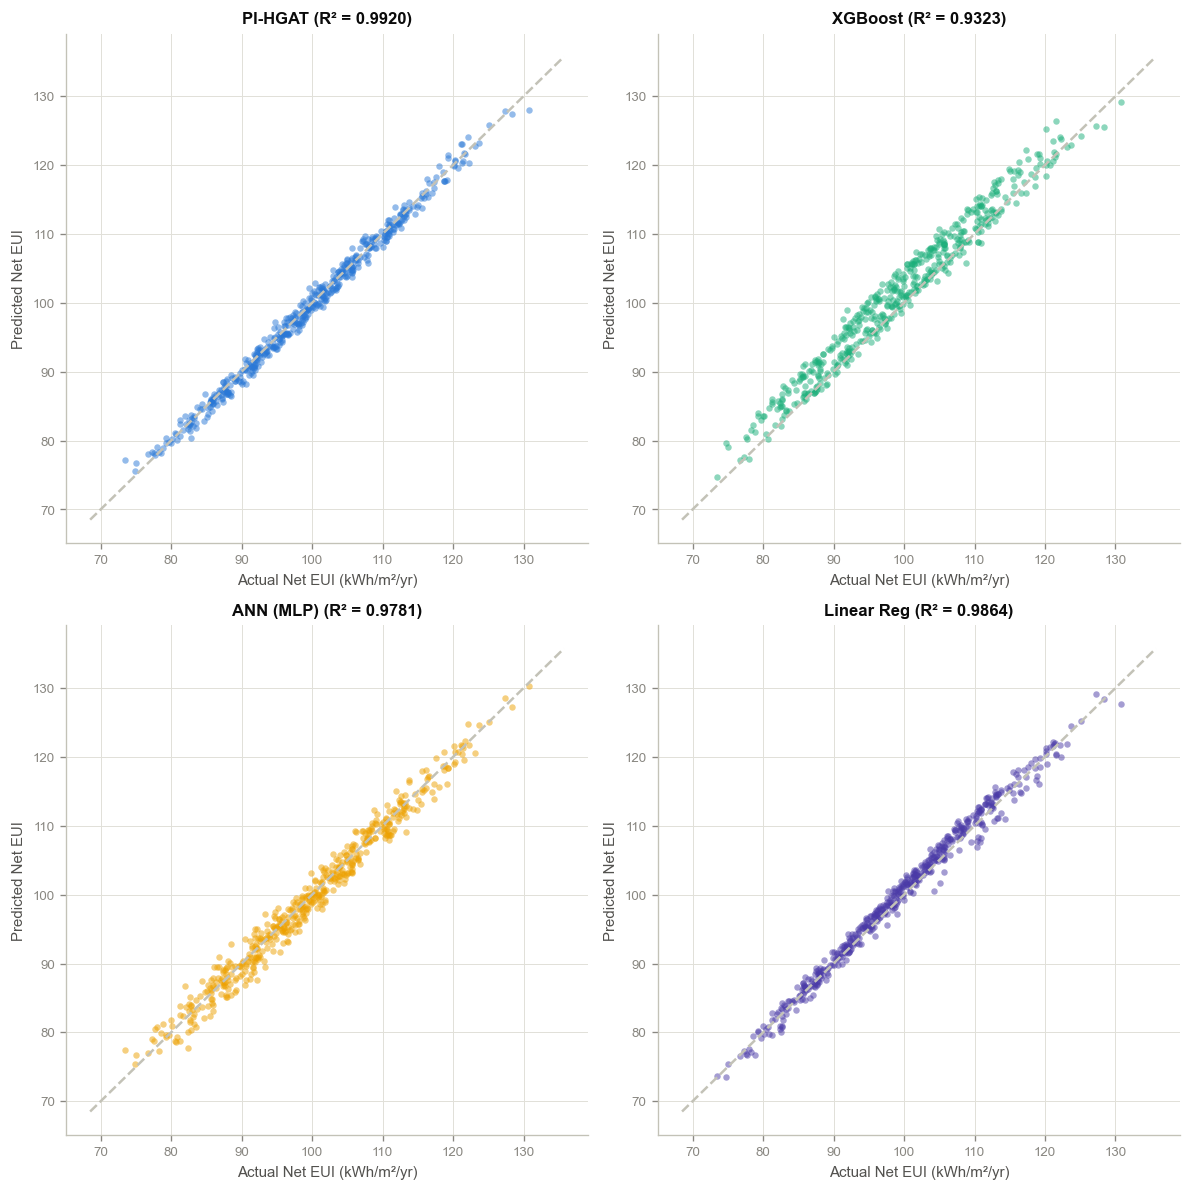

Saved: results/figures/Fig6_BenchmarkBar.png|.pdf


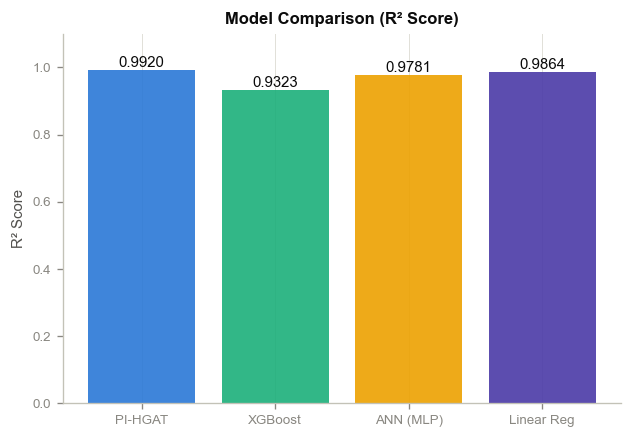

Saved: results/figures/Fig7_LearningCurve.png|.pdf


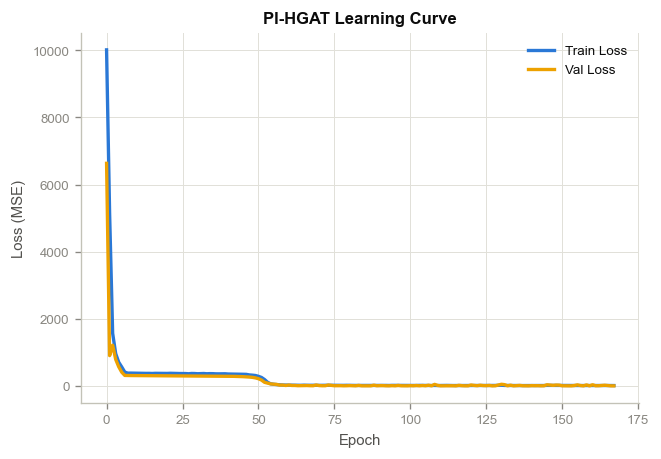

In [10]:
# FIGURE 5, 6, 7
from scripts.analysis.fig_style import apply_style, savefig, MODEL_COLORS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gọi lại apply_style trước mỗi plot để chống Jupyter override
apply_style()

# --- FIG 5: Predicted vs Actual (4-panel) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
targets = [(hgat_t, hgat_p, 'PI-HGAT'), (Yte, xgb_p, 'XGBoost'), 
           (Yte, ann_p, 'ANN (MLP)'), (Yte, lr_p, 'Linear Reg')]

for i, ax in enumerate(axes.flatten()):
    yt, yp, name = targets[i]
    color = MODEL_COLORS.get(name, '#000000')
    ax.scatter(yt, yp, alpha=0.5, s=15, color=color)
    
    lims = [min(yt.min(), yp.min()) - 5, max(yt.max(), yp.max()) + 5]
    ax.plot(lims, lims, '--', lw=1.5, color='#c3c2b7')
    r2 = df.loc[name, 'R²']
    ax.set_title(f'{name} (R² = {r2:.4f})', fontname='Arial', fontweight='bold')
    ax.set_xlabel('Actual Net EUI (kWh/m²/yr)', fontname='Arial')
    ax.set_ylabel('Predicted Net EUI', fontname='Arial')

plt.tight_layout()
savefig(fig, 'Fig5_PredictionPerf')
plt.show()

# --- FIG 6: Benchmark Bar Chart (R2) ---
apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
colors = [MODEL_COLORS[m] for m in df.index]
bars = ax.bar(df.index, df['R²'], color=colors, alpha=0.9)

for bar, val in zip(bars, df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontname='Arial', color='#0b0b0b')

ax.set_title('Model Comparison (R² Score)', fontname='Arial', fontweight='bold')
ax.set_ylabel('R² Score', fontname='Arial')
ax.set_ylim(0, 1.1)
ax.grid(axis='y') # Tắt lưới dọc, chỉ giữ lưới ngang cho bar chart
# Ép tick labels dùng Arial
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial')
    
savefig(fig, 'Fig6_BenchmarkBar')
plt.show()

# --- FIG 7: Learning Curve (PI-HGAT) ---
apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist['train'], label='Train Loss', color=MODEL_COLORS['PI-HGAT'], lw=2)
ax.plot(hist['val'], label='Val Loss', color='#eda100', lw=2) 
ax.set_title('PI-HGAT Learning Curve', fontname='Arial', fontweight='bold')
ax.set_xlabel('Epoch', fontname='Arial')
ax.set_ylabel('Loss (MSE)', fontname='Arial')

# Ép tick labels dùng Arial
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial')
    
ax.legend(prop={'family': 'Arial', 'size': 8})
savefig(fig, 'Fig7_LearningCurve')
plt.show()


## PART 2 · Section 11 — NSGA-III Problem Definition (f1 EUI | f2 LCC | f3 LCE)
f1 = PI-HGAT surrogate (site EUI, demand-side); f2/f3 = `pi_hgat/objectives.py`
(Kadric-style IC+OC+MC and EN 15978 modules A1-A3, A4-A5, B2-B3, B4, B6, C1-C4),
20-yr / 8%-real basis from `pi_hgat/config.py`. PV (P8) and BESS (P9) enter here
via net-energy post-processing, not through the surrogate.


In [11]:
from pymoo.core.problem import ElementwiseProblem
from pi_hgat.objectives import ObjectiveCalculator
import torch
import pandas as pd

# Initialize objectives calculator
obj_calc = ObjectiveCalculator(builder)

class NZEBRetrofitProblem(ElementwiseProblem):
    def __init__(self, model_surrogate, builder):
        # 10 variables (P1..P9 + Climate). Climate is fixed to HCMC mean for MOO.
        self.var_names = ['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U', 'P4_Win_SHGC', 'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'P8_PV_kW', 'P9_BESS_kWh']
        super().__init__(n_var=10, n_obj=3, n_ieq_constr=0,
                         xl=np.array([0.29, 0.18, 0.30, 1.00, 0.15, 2.96, 24.0, 2.50, 0.0, 0.0]),
                         xu=np.array([1.07, 0.45, 0.85, 2.87, 0.22, 5.00, 27.0, 6.66, 150.0, 150.0]))
        self.model = model_surrogate
        self.model.eval()
        self.builder = builder

    def _evaluate(self, x, out, *args, **kwargs):
        # 1. Map decision variables
        params = {
            'P1_Wall_U': x[0], 'P2_Roof_U': x[1], 'P3_Roof_Reflectance': x[2],
            'P4_Win_U': x[3], 'P4_Win_SHGC': x[4], 'P5_COP': x[5],
            'P6_Cool_SP': x[6], 'P7_LPD': x[7], 'P8_PV_kW': x[8], 'P9_BESS_kWh': x[9],
            'Climate_DeltaT': 0.0  # Assume mean climate for design optimization
        }
        
        # 2. Predict Gross EUI using PI-HGAT
        data = self.builder.create_sample_graph(params)
        
        x_flat = [params['P1_Wall_U'], params['P2_Roof_U'], params['P3_Roof_Reflectance'],
                  params['P4_Win_U'], params['P4_Win_SHGC'], params['P5_COP'],
                  params['P6_Cool_SP'], params['P7_LPD'], params['P8_PV_kW'], params['P9_BESS_kWh'], params['Climate_DeltaT']]
        data.global_params = torch.tensor([x_flat], dtype=torch.float)
        
        with torch.no_grad():
            batch_dict = {nt: torch.zeros(data[nt].x.size(0), dtype=torch.long, device=device) 
                          for nt in data.node_types}
            out_eui = self.model(
                {nt: data[nt].x.to(device) for nt in data.node_types},
                {et: data[et].edge_index.to(device) for et in data.edge_types},
                batch_dict,
                data.global_params.to(device)
            )
            gross_eui = out_eui.item()
            
        # Post-process Net EUI
        pv_yield = 1420.0
        pv_gen_kwh = params['P8_PV_kW'] * pv_yield
        daily_pv = pv_gen_kwh / 365.0
        bess_ratio = params['P9_BESS_kWh'] / daily_pv if daily_pv > 0 else 0
        sc_factor = min(1.0, 0.6 + 0.4 * min(1.0, bess_ratio))
        net_eui = max(0.0, gross_eui - (pv_gen_kwh * sc_factor / 4982.0))
            
        # 3. Calculate LCC and LCA (using NET EUI for operational costs/emissions)
        lcc = obj_calc.calculate_lcc(params, net_eui)
        lca = obj_calc.calculate_lca(params, net_eui)
        
        # 4. Assign objectives (Minimize all)
        out["F"] = [net_eui, lcc, lca]

problem = NZEBRetrofitProblem(model, builder)
print("MOO Problem Defined: 10 Variables, 3 Objectives (EUI, LCC, LCA)")
bounds_df = pd.DataFrame({'Lower Bound': problem.xl, 'Upper Bound': problem.xu}, index=problem.var_names)
print('\nDecision Variable Bounds (jEPlus scale):')
display(bounds_df)


MOO Problem Defined: 10 Variables, 3 Objectives (EUI, LCC, LCA)

Decision Variable Bounds (jEPlus scale):


,Lower Bound,Upper Bound
P1_Wall_U,0.29,1.07
P2_Roof_U,0.18,0.45
P3_Roof_Reflectance,0.30,0.85
P4_Win_U,1.00,2.87
P4_Win_SHGC,0.15,0.22
P5_COP,2.96,5.00
P6_Cool_SP,24.00,27.00
P7_LPD,2.50,6.66
P8_PV_kW,0.00,150.00
P9_BESS_kWh,0.00,150.00


> ### 📊 FIGURE SLOT — **Fig. 3 · Component lifespans vs 20-yr study period** *(PART 2, setup)*
> Barh lifespan P1–P9 (`config.LIFESPANS_SHORT`) + vạch dọc 20 năm; đánh dấu các measure có replacement (P5@15, P7@12, P9@15). Số liệu THẬT từ config — có thể vẽ ngay. **Status:** ⬜ dễ, làm ngay được
>
> ### 📊 FIGURE SLOT — **Fig. 4 · Embodied LCE by module @ max renovation** *(PART 2, setup)*
> Stacked bar 5 module embodied (A1-A3→C1-C4, ordinal blues `LCA_COLORS`), **B6 loại ra** (theo Kadrić Fig.4); mỗi measure P1–P9 một cột. **Data:** `obj_calc.calculate_lca_breakdown()` @ level max. **Status:** ⬜


Saved: results/figures/Fig3_Lifespan.png|.pdf


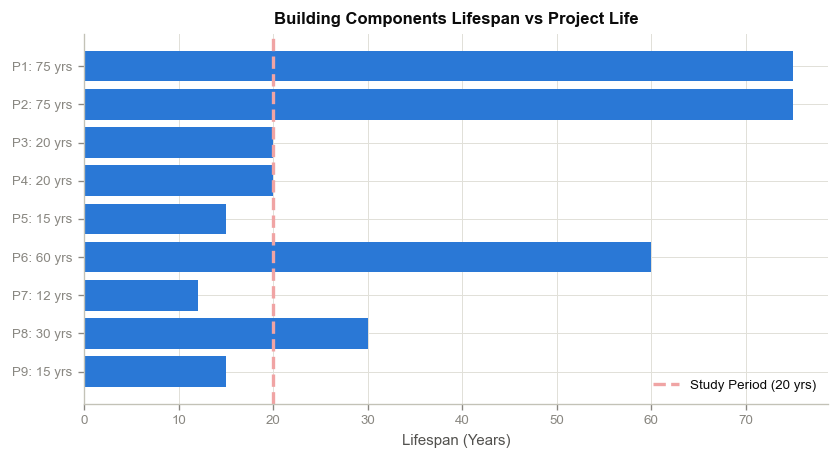

Saved: results/figures/Fig4_LCEDistribution.png|.pdf


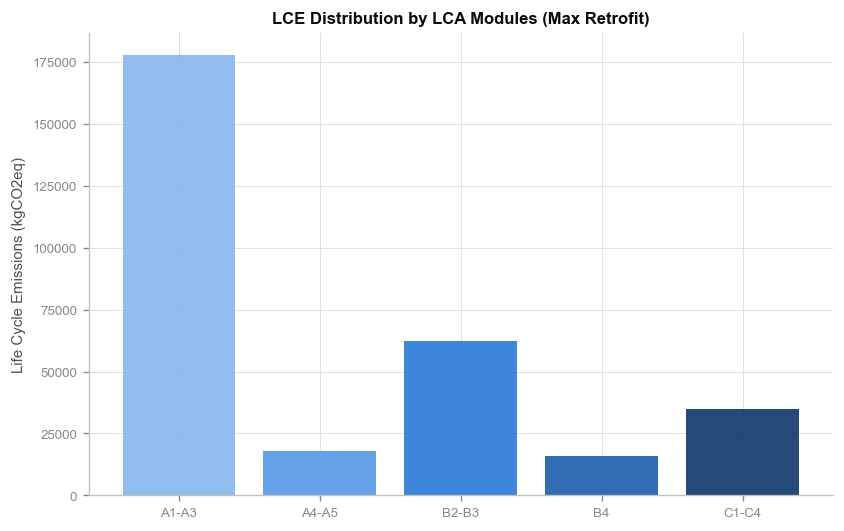

In [12]:
# FIGURE 3 & 4
from scripts.analysis.fig_style import apply_style, savefig, LCA_COLORS
import matplotlib.pyplot as plt
import numpy as np
from pi_hgat.config import LIFESPANS_SHORT
apply_style()

# --- FIG 3: Lifespans ---
fig, ax = plt.subplots(figsize=(8, 4))
components = [f'{k}: {v} yrs' for k, v in LIFESPANS_SHORT.items()]
lifespans = list(LIFESPANS_SHORT.values())
y_pos = np.arange(len(components))
ax.barh(y_pos, lifespans, color='#2a78d6', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(components)
ax.invert_yaxis()
ax.set_xlabel('Lifespan (Years)')
ax.set_title('Building Components Lifespan vs Project Life')
ax.axvline(x=20, color='#f0a4a4', linestyle='--', linewidth=2, label='Study Period (20 yrs)')
ax.legend(loc='lower right')
savefig(fig, 'Fig3_Lifespan')
plt.show()

# --- FIG 4: LCA Modules at Max Level ---
params_max = {
    'P1_Wall_U': 0.29, 'P2_Roof_U': 0.18, 'P3_Roof_Reflectance': 0.85,
    'P4_Win_U': 1.00, 'P4_Win_SHGC': 0.15, 'P5_COP': 5.00,
    'P6_Cool_SP': 27.0, 'P7_LPD': 2.50, 'P8_PV_kW': 150.0, 'P9_BESS_kWh': 150.0
}
lca_breakdown = obj_calc.calculate_lca_breakdown(params_max, 80.0) 
modules = ['A1-A3', 'A4-A5', 'B2-B3', 'B4', 'C1-C4']
vals = [lca_breakdown[m] for m in modules]
colors = [LCA_COLORS[m] for m in modules]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(modules, vals, color=colors, edgecolor='black', alpha=0.9)
ax.set_ylabel('Life Cycle Emissions (kgCO2eq)')
ax.set_title('LCE Distribution by LCA Modules (Max Retrofit)')
savefig(fig, 'Fig4_LCEDistribution')
plt.show()


## PART 2 · Section 12 — Run NSGA-III
Produces the Pareto front (**Fig. 6** evolution, **Fig. 7** pairwise).


In [13]:
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions

# Generate reference directions for NSGA-III (3 objectives)
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)

algorithm = NSGA3(pop_size=92, ref_dirs=ref_dirs)  # pop_size 92 is better for n_partitions=12

print("Running NSGA-III optimization... (This may take a minute)")
import time
t0 = time.time()
res = minimize(problem,
               algorithm,
               seed=42,
               termination=('n_gen', 50),
               save_history=True,
               verbose=True)

print(f"Optimization finished in {time.time()-t0:.1f}s")
print(f"Found {len(res.F)} Pareto optimal solutions.")

Running NSGA-III optimization... (This may take a minute)
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       92 |      5 |             - |             -
     2 |      184 |      4 |  0.0230719245 |         ideal
     3 |      276 |      5 |  0.1404144938 |         ideal
     4 |      368 |      6 |  0.2264741867 |         ideal
     5 |      460 |      6 |  0.1051702184 |             f
     6 |      552 |      8 |  0.1750032825 |         ideal
     7 |      644 |      8 |  0.1853350118 |         ideal
     8 |      736 |      9 |  0.2546523017 |         ideal
     9 |      828 |      9 |  0.3078565329 |         ideal
    10 |      920 |      5 |  3.3025762989 |         ideal
    11 |     1012 |      7 |  0.8152667272 |         ideal
    12 |     1104 |      6 |  0.0324212172 |         ideal
    13 |     1196 |     13 |  0.0272274881 |         ideal
    14 |     1288 |     18 |  0.0288925941 |         ideal
    15 |     1380 |     10 |  0.0821983233 |         idea

> ### 📊 FIGURE SLOT — **Fig. 8 · Pareto front + convergence** *(PART 2)*
> (a) 3D Pareto (EUI–LCC–LCE) màu TOPSIS (`seq_cmap`); (b) hypervolume theo generation (cần `save_history=True` trong `minimize`). **THAY THẾ** Fig6 mock "evolution" cũ — hypervolume là bằng chứng hội tụ chuẩn hơn scatter. **Status:** ⬜


Saved: results/figures/Fig8_Pareto3D.png|.pdf


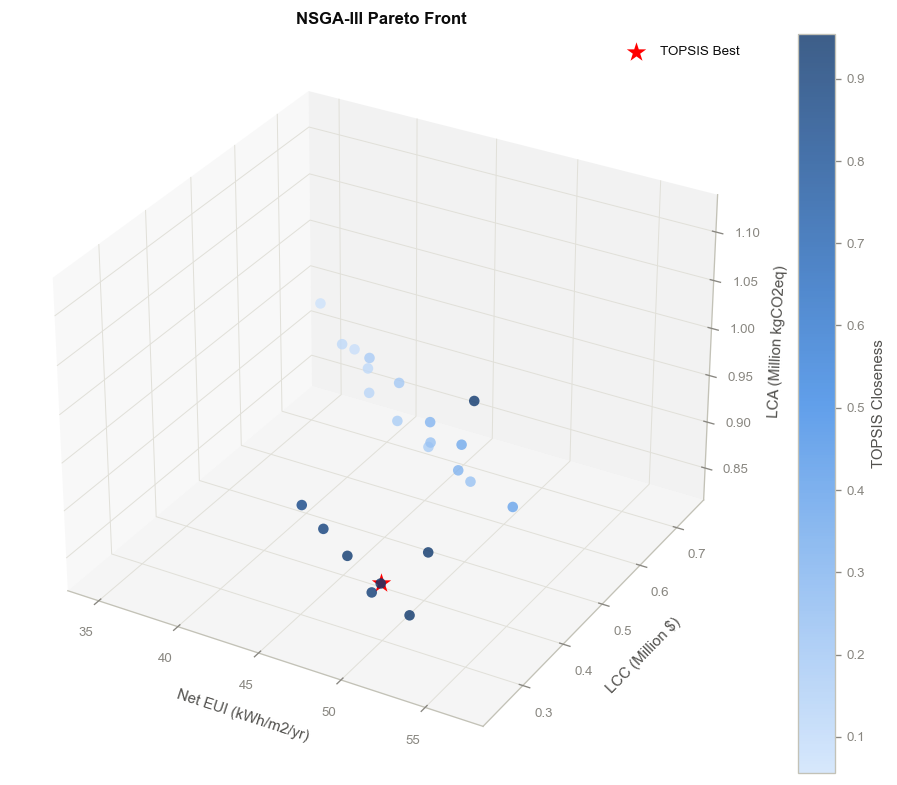

Saved: results/figures/Fig8b_Convergence.png|.pdf


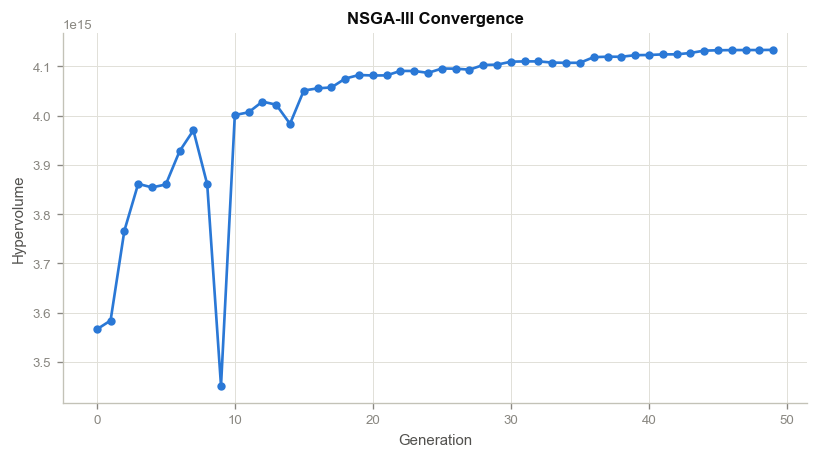

In [14]:
# FIGURE 8
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
import matplotlib.pyplot as plt
apply_style()

import numpy as np
F = res.F
norm_F = F / np.sqrt((F**2).sum(axis=0))
P = norm_F / norm_F.sum(axis=0)
E = -np.nansum(P * np.log(P), axis=0) / np.log(len(F))
W = (1 - E) / (1 - E).sum()
V = norm_F * W
ideal = V.min(axis=0)
anti_ideal = V.max(axis=0)
d_ideal = np.sqrt(((V - ideal)**2).sum(axis=1))
d_anti = np.sqrt(((V - anti_ideal)**2).sum(axis=1))
closeness = d_anti / (d_ideal + d_anti)
best_idx = np.argmax(closeness)
best_obj = res.F[best_idx]


# --- FIG 8a: 3D Pareto ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F[:, 0], F[:, 1]/1e6, F[:, 2]/1e6, c=closeness, cmap=seq_cmap(), s=40, alpha=0.8)
ax.scatter(best_obj[0], best_obj[1]/1e6, best_obj[2]/1e6, color='red', s=150, marker='*', label='TOPSIS Best')

ax.set_xlabel('Net EUI (kWh/m2/yr)')
ax.set_ylabel('LCC (Million $)')
ax.set_zlabel('LCA (Million kgCO2eq)')
ax.set_title('NSGA-III Pareto Front')
plt.colorbar(sc, label='TOPSIS Closeness')
plt.legend()
savefig(fig, 'Fig8_Pareto3D')
plt.show()

# --- FIG 8b: Convergence (Hypervolume) ---
if res.history is not None:
    from pymoo.indicators.hv import Hypervolume
    ref_point = np.array([200.0, 3e6, 1e7])
    hv = Hypervolume(ref_point=ref_point)
    hv_history = []
    for algo in res.history:
        opt = algo.opt
        if len(opt) > 0:
            hv_history.append(hv.do(opt.get("F")))
        else:
            hv_history.append(0.0)
            
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hv_history, color='#2a78d6', marker='o', markersize=4)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Hypervolume')
    ax.set_title('NSGA-III Convergence')
    savefig(fig, 'Fig8b_Convergence')
    plt.show()


## PART 2 · Section 13 — Entropy-TOPSIS Ranking & Pareto Visualization
Entropy-weighted TOPSIS closeness coefficient over the Pareto set
(**Fig. 8** decision variables, **Fig. 9** TOPSIS-coloured front, **Fig. 11** heatmap).


In [15]:
from scipy.stats import entropy
import pandas as pd
import os

F = res.F

# --- Entropy-TOPSIS ---
# 1. Normalize Decision Matrix
norm_F = F / np.sqrt((F**2).sum(axis=0))

# 2. Calculate Entropy Weights
P = norm_F / norm_F.sum(axis=0)
E = -np.nansum(P * np.log(P), axis=0) / np.log(len(F))
W = (1 - E) / (1 - E).sum()
print(f"Objective Weights (Entropy): EUI={W[0]:.3f}, LCC={W[1]:.3f}, LCA={W[2]:.3f}")

# 3. Weighted Normalized Matrix
V = norm_F * W

# 4. Ideal and Anti-Ideal Solutions (Cost criteria: min is ideal)
ideal = V.min(axis=0)
anti_ideal = V.max(axis=0)

# 5. Distances & Closeness
d_ideal = np.sqrt(((V - ideal)**2).sum(axis=1))
d_anti = np.sqrt(((V - anti_ideal)**2).sum(axis=1))
closeness = d_anti / (d_ideal + d_anti)

best_idx = np.argmax(closeness)
best_solution = res.X[best_idx]
best_obj = res.F[best_idx]

print("\n===== OPTIMAL COMPROMISE SOLUTION (TOPSIS) =====")
print(f"EUI: {best_obj[0]:.2f} kWh/m2/yr")
print(f"LCC: ${best_obj[1]:,.2f}")
print(f"LCA: {best_obj[2]:,.2f} kgCO2eq")
print(f"Parameters: P1={best_solution[0]:.2f}, P2={best_solution[1]:.2f}, P3={best_solution[2]:.2f}, "
      f"P4_U={best_solution[3]:.2f}, P4_SHGC={best_solution[4]:.2f}, P5={best_solution[5]:.2f}, "
      f"P6={best_solution[6]:.1f}, P7={best_solution[7]:.2f}, P8={best_solution[8]:.1f}kW, "
      f"P9={best_solution[9]:.1f}kWh")

# Save pareto_solutions.csv
df_pareto = pd.DataFrame(res.X, columns=['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U', 'P4_Win_SHGC', 'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'P8_PV_kW', 'P9_BESS_kWh'])
df_pareto['EUI'] = res.F[:, 0]
df_pareto['LCC'] = res.F[:, 1]
df_pareto['LCA'] = res.F[:, 2]
df_pareto['Closeness'] = closeness
df_pareto['NZE_class'] = np.where(df_pareto['EUI'] <= 0.0, 'NZE', 'Near-NZE')

os.makedirs('results', exist_ok=True)
df_pareto.to_csv('results/pareto_solutions.csv', index=False)
print(f"\nSaved {len(df_pareto)} solutions to results/pareto_solutions.csv")
print(df_pareto['NZE_class'].value_counts())


Objective Weights (Entropy): EUI=0.098, LCC=0.881, LCA=0.021

===== OPTIMAL COMPROMISE SOLUTION (TOPSIS) =====
EUI: 51.25 kWh/m2/yr
LCC: $248,521.83
LCA: 903,658.20 kgCO2eq
Parameters: P1=0.76, P2=0.32, P3=0.31, P4_U=1.02, P4_SHGC=0.21, P5=3.52, P6=25.3, P7=2.53, P8=149.9kW, P9=12.8kWh

Saved 23 solutions to results/pareto_solutions.csv
NZE_class
Near-NZE    23
Name: count, dtype: int64


> ### 📊 FIGURE SLOT — **Fig. 9 · Pairwise Pareto colored by TOPSIS** *(PART 2)*
> 3 panel EUI–LCC / EUI–LCE / LCC–LCE, màu = closeness (`seq_cmap`), ★ = compromise. GỘP Fig7 (pairwise trơn) vào đây — Fig7 cũ **bỏ** vì trùng. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 10 · LCE by module: Baseline vs Optimal vs Max** *(PART 2)*
> GỘP Fig4-cũ + Fig10-cũ thành 1 hình 3 cột nhóm (module màu `LCA_COLORS` + B6 aqua) — kể trọn câu chuyện NZEB-paradox trong 1 hình. **Data:** `calculate_lca_breakdown()` cho 3 cấu hình. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 11 · Renovation-level heatmap of Pareto set** *(PART 2)*
> Heatmap (P1–P9 × solutions xếp theo TOPSIS, `seq_cmap`, level chuẩn hóa 0–1). **Kadrić Fig.11.** **Status:** ⬜
>
> **💾 BẮT BUỘC:** lưu `res.X`, `res.F`, `closeness` → `results/pareto_solutions.csv` để mọi figure tái lập được.


Saved: results/figures/Fig9_Pairwise.png|.pdf


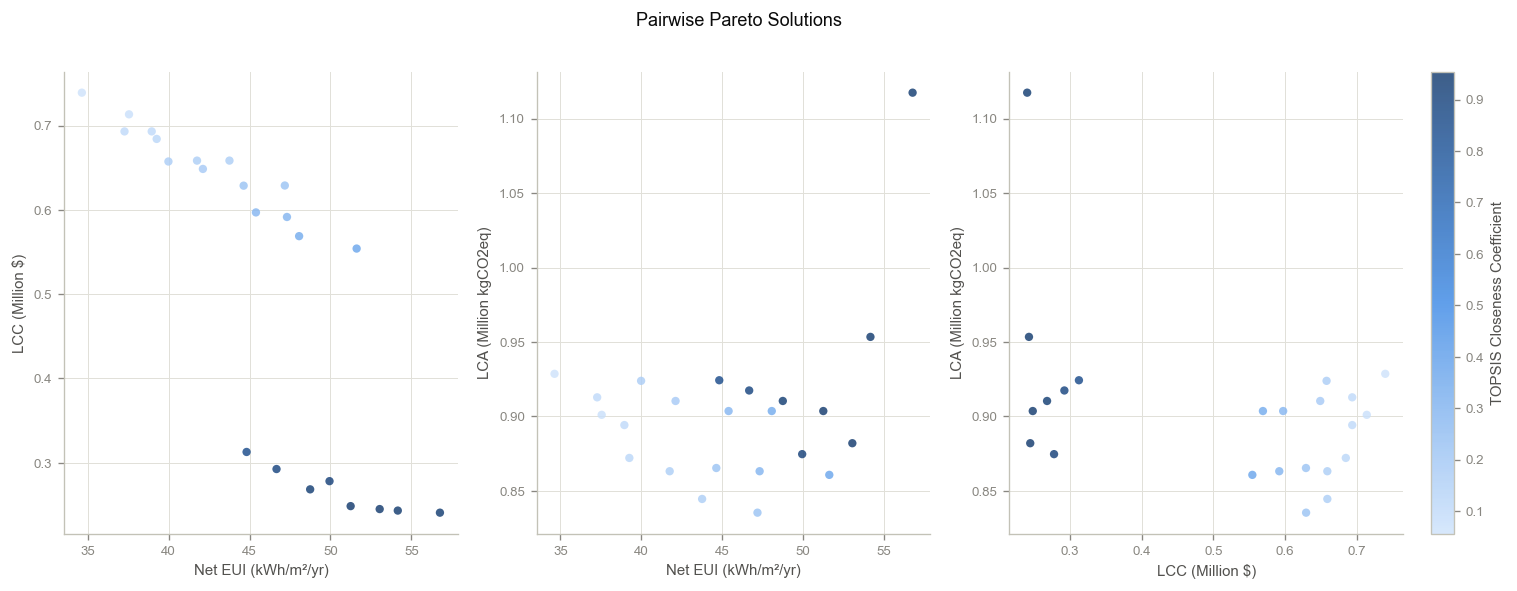

Saved: results/figures/Fig11_Heatmap.png|.pdf


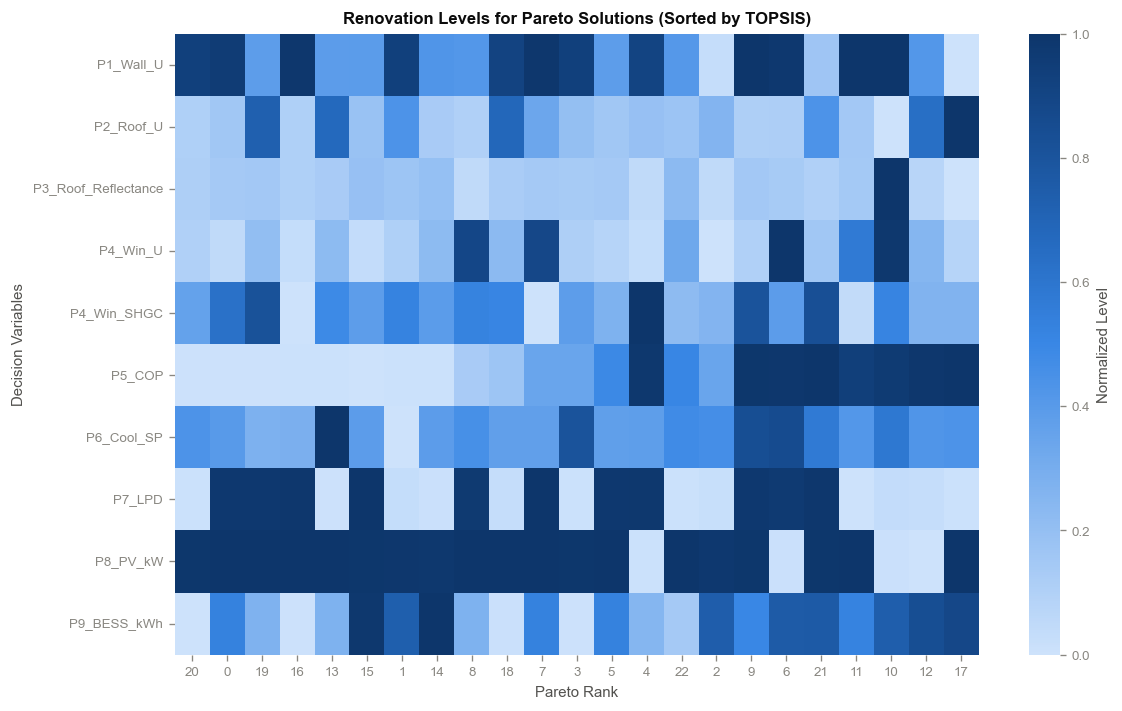

In [16]:
# FIGURE 9, 10, 11
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
apply_style()

# --- FIG 9: Pairwise Pareto ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Net EUI (kWh/m²/yr)', 'LCC (Million $)', 'LCA (Million kgCO2eq)']
pairs = [(0, 1), (0, 2), (1, 2)]

for i, ax in enumerate(axes):
    idx_x, idx_y = pairs[i]
    x_data = F[:, idx_x] if idx_x == 0 else F[:, idx_x] / 1e6
    y_data = F[:, idx_y] if idx_y == 0 else F[:, idx_y] / 1e6
    
    sc = ax.scatter(x_data, y_data, c=closeness, cmap=seq_cmap(), s=25, alpha=0.8)
    ax.set_xlabel(labels[idx_x])
    ax.set_ylabel(labels[idx_y])

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('TOPSIS Closeness Coefficient')
fig.suptitle('Pairwise Pareto Solutions')
savefig(fig, 'Fig9_Pairwise')
plt.show()

# --- FIG 11: Heatmap ---
df_pareto = pd.read_csv('results/pareto_solutions.csv')
df_pareto_sorted = df_pareto.sort_values(by='Closeness', ascending=False)
X_pareto = df_pareto_sorted[['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U', 'P4_Win_SHGC', 'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'P8_PV_kW', 'P9_BESS_kWh']]

X_min = X_pareto.min()
X_max = X_pareto.max()
X_norm = (X_pareto - X_min) / (X_max - X_min + 1e-9)

plt.figure(figsize=(10, 6))
sns.heatmap(X_norm.T, cmap=seq_cmap(), cbar_kws={'label': 'Normalized Level'})
plt.title('Renovation Levels for Pareto Solutions (Sorted by TOPSIS)')
plt.xlabel('Pareto Rank')
plt.ylabel('Decision Variables')
plt.tight_layout()
savefig(plt.gcf(), 'Fig11_Heatmap')
plt.show()


## PART 3 · Section 14 — Spatial Explainability (GNNExplainer)
Explains the recommended retrofit package: which zones/surfaces/edges drive the EUI
prediction (paper Fig.: explanation subgraph + trade-off report).


In [17]:
from torch_geometric.explain import Explainer, GNNExplainer
import networkx as nx

# Prepare data using Best Compromise Solution from TOPSIS
best_params = {
    'P1_Wall_U': best_solution[0], 'P2_Roof_U': best_solution[1], 'P3_Roof_Reflectance': best_solution[2],
    'P4_Win_U': best_solution[3], 'P4_Win_SHGC': best_solution[4], 'P5_COP': best_solution[5],
    'P6_Cool_SP': best_solution[6], 'P7_LPD': best_solution[7], 'P8_PV_kW': best_solution[8], 
    'P9_BESS_kWh': best_solution[9],
    'Climate_DeltaT': 0.0
}

data = builder.create_sample_graph(best_params)
data.global_params = torch.tensor([[best_solution[0], best_solution[1], best_solution[2],
                                    best_solution[3], best_solution[4], best_solution[5],
                                    best_solution[6], best_solution[7], best_solution[8], 
                                    best_solution[9], 0.0]], dtype=torch.float)


batch_dict = {nt: torch.zeros(data[nt].x.size(0), dtype=torch.long, device=device) for nt in data.node_types}
data = data.to(device)
data.global_params = data.global_params.to(device)

class ModelWrapper(torch.nn.Module):
    def __init__(self, model, batch_dict, global_params):
        super().__init__()
        self.model = model
        self.batch_dict = batch_dict
        self.global_params = global_params
    def forward(self, x_dict, edge_index_dict):
        return self.model(x_dict, edge_index_dict, self.batch_dict, self.global_params)

wrapped_model = ModelWrapper(model, batch_dict, data.global_params)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(mode='regression', task_level='graph', return_type='raw')
)

print("Running GNNExplainer (learning masks for mutual information)...")
explanation = explainer(data.x_dict, data.edge_index_dict)
print("Explanation completed.")

feat_names = {
    'Zone': ['area', 'volume', 'height', 'LPD', 'PV_share'],
    'Envelope': ['area', 'tilt', 'azimuth', 'is_wall', 'is_roof', 'is_floor', 'is_window', 'U-value', 'Reflectance', 'SHGC', 'ShapeIndex'],
    'System': ['cooling_cap', 'heating_cap', 'COP', 'Cool_SP', 'Heat_SP']
}

print("\n--- Top Node Features by Mask Score ---")
for nt in ['Zone', 'Envelope', 'System']:
    mask = explanation.node_mask_dict[nt].cpu().numpy()
    mean_mask = mask.mean(axis=0)
    top_idx = mean_mask.argsort()[::-1][:3]
    print(f"\n{nt} Features:")
    for i in top_idx:
        print(f"  - {feat_names[nt][i]}: {mean_mask[i]:.4f}")

Running GNNExplainer (learning masks for mutual information)...
Explanation completed.

--- Top Node Features by Mask Score ---

Zone Features:
  - PV_share: 0.7178
  - height: 0.6885
  - volume: 0.6248

Envelope Features:
  - ShapeIndex: 0.8014
  - tilt: 0.7387
  - area: 0.4832

System Features:
  - cooling_cap: 0.8138
  - heating_cap: 0.8120
  - Heat_SP: 0.8106


> ### 📊 FIGURE SLOT — **Fig. 12 · Global feature importance per node type** *(PART 3)*
> Barh mask score GNNExplainer nhóm theo Zone/Envelope/System (kiểu GAT-BEM Fig.7–8) + SHAP beeswarm trên global params (XGBoost surrogate đối chiếu, `div_cmap` xanh↔đỏ). **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 13 · Edge-type (connection) importance** *(PART 3)*
> Bar importance theo edge type (Zone–Envelope, Zone–System, Zone–Zone adjacency…) từ `explanation.edge_mask_dict` — GAT-BEM Fig.9. Đây là bằng chứng "bảo toàn quan hệ không gian". **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 14 · Spatial explanation map** *(PART 3 — contribution figure)*
> Floor-plan/axonometric DOE Medium Office, zone tô màu theo node-importance (`seq_cmap`) + top-k edges vẽ đè; kèm (b) scatter centrality-vs-importance (GAT-BEM Fig.10 "thermal centrality"). **Status:** ⬜


Saved: results/figures/Fig12a_NodeImportance.png|.pdf


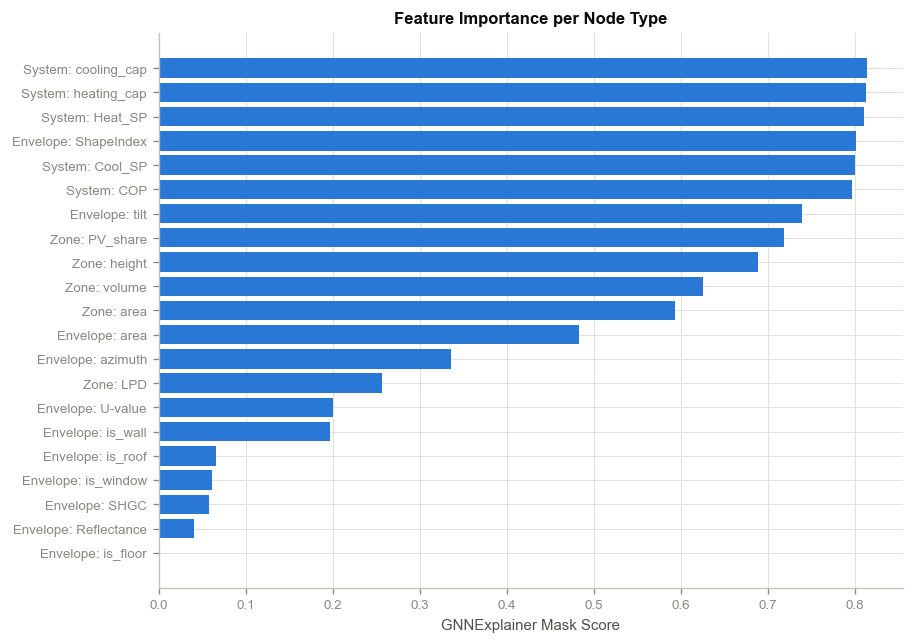

Saved: results/figures/Fig12b_SHAP.png|.pdf


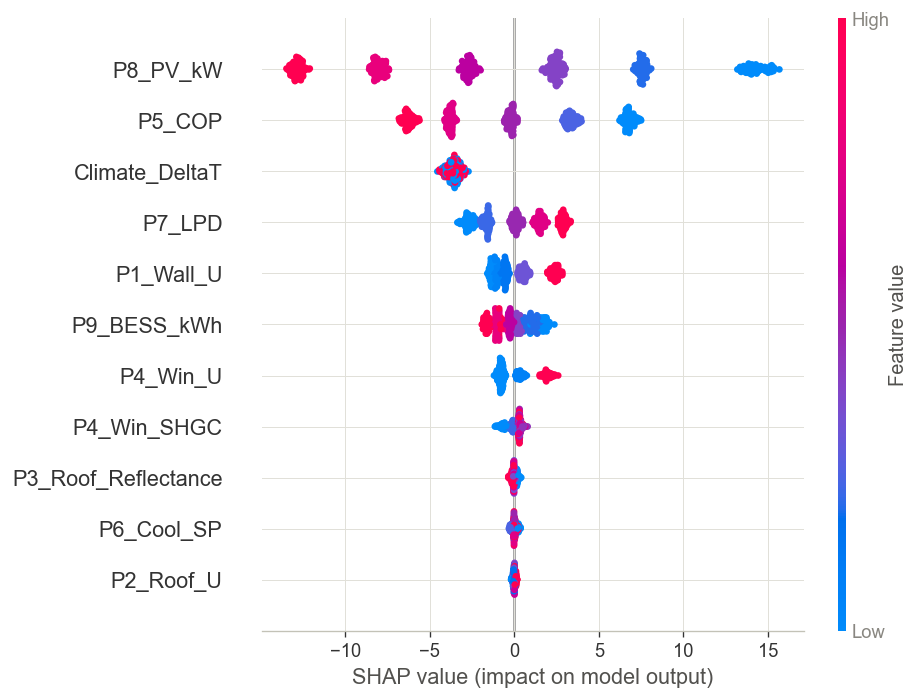

Saved: results/figures/Fig13_EdgeImportance.png|.pdf


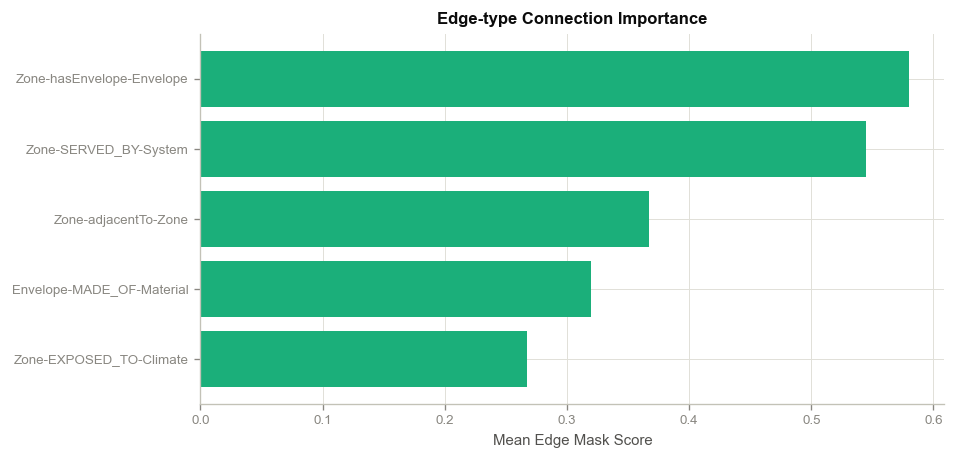

In [18]:
# FIGURE 12, 13, 14
from scripts.analysis.fig_style import apply_style, savefig
import matplotlib.pyplot as plt
import numpy as np
import shap
apply_style()

# --- FIG 12a: Global Feature Importance (GNNExplainer) ---
importances = []
labels = []
for nt in ['Zone', 'Envelope', 'System']:
    mask = explanation.node_mask_dict[nt].cpu().numpy().mean(axis=0)
    for i, score in enumerate(mask):
        importances.append(score)
        labels.append(f"{nt}: {feat_names[nt][i]}")
        
idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(labels)[idx], np.array(importances)[idx], color='#2a78d6')
ax.set_xlabel('GNNExplainer Mask Score')
ax.set_title('Feature Importance per Node Type')
savefig(fig, 'Fig12a_NodeImportance')
plt.show()

# --- FIG 12b: SHAP Beeswarm (XGBoost) ---
explainer_xgb = shap.Explainer(xgb_model)
shap_values = explainer_xgb(Xte_s)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, Xte, feature_names=problem.var_names + ['Climate_DeltaT'], show=False)
savefig(plt.gcf(), 'Fig12b_SHAP')
plt.show()

# --- FIG 13: Edge-type Importance ---
edge_importances = []
edge_labels = []
for et in data.edge_types:
    mask = explanation.edge_mask_dict[et].cpu().numpy().mean()
    edge_importances.append(mask)
    edge_labels.append(f"{et[0]}-{et[1]}-{et[2]}")
    
idx_e = np.argsort(edge_importances)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.array(edge_labels)[idx_e], np.array(edge_importances)[idx_e], color='#1baf7a')
ax.set_xlabel('Mean Edge Mask Score')
ax.set_title('Edge-type Connection Importance')
savefig(fig, 'Fig13_EdgeImportance')
plt.show()
